# Inspect arXiv Structural Rewrite Pilot

This notebook visualizes the 20-row LLM-rewritten arXiv structural QA pilot.

It provides:

- A quick-reference table with original vs rewritten questions.
- Rewrite validation / answer-quality flags from the pilot JSONL.
- Per-row document page visualization with involved-page highlighting.
- Optional LongDocURL structural examples for style comparison.

The default input is the clean pilot generated with `gpt-5.6-luna`.


In [10]:
from __future__ import annotations

import json
import re
from pathlib import Path
from urllib.parse import unquote, urlparse

import pandas as pd
from IPython.display import HTML, Image, display

PARQUET_PATH = Path(
    "/scratch/ywxzml3j/likaican/src/verl-qwen3-vl/notes/generated/"
    "arxiv_struct_rewrite_pilot_20_clean_20260722/rewritten_sample.parquet"
)
JSONL_PATH = Path(
    "/scratch/ywxzml3j/likaican/src/verl-qwen3-vl/notes/generated/"
    "arxiv_struct_rewrite_pilot_20_clean_20260722/rewritten_sample.jsonl"
)
LONGDOCURL_PATH = Path(
    "/scratch/ywxzml3j/likaican/src/verl-qwen3-vl/notes/generated/"
    "testcase_0504_full_parquets/longdocurl_full-insight_qwen_agent.parquet"
)

pd.set_option("display.max_colwidth", 220)
pd.set_option("display.max_rows", 200)


## Helpers

In [11]:
VISUAL_LABEL_RE = re.compile(
    r"\b(?:tables?|tabs?\.?|figs?\.?|figures?)\s*[\(\[]?\s*"
    r"[A-Za-z]?\d+(?:[.\-]\s*[A-Za-z0-9]+)*[A-Za-z]?\b",
    re.I,
)


def as_dict(value):
    if isinstance(value, dict):
        return value
    if isinstance(value, str):
        try:
            obj = json.loads(value)
            return obj if isinstance(obj, dict) else {}
        except Exception:
            return {}
    return {}


def as_list(value):
    if value is None:
        return []
    if hasattr(value, "tolist"):
        return value.tolist()
    if isinstance(value, (list, tuple)):
        return list(value)
    return [value]


def clean_question(text: str) -> str:
    return re.sub(r"(?:<image>)+", "", str(text)).strip()


def get_user_question(prompt) -> str:
    for msg in as_list(prompt):
        if not isinstance(msg, dict) or msg.get("role") != "user":
            continue
        content = msg.get("content", "")
        if isinstance(content, str):
            return clean_question(content)
        if isinstance(content, list):
            parts = []
            for item in content:
                if isinstance(item, dict) and item.get("type") == "text":
                    parts.append(item.get("text", ""))
                elif isinstance(item, str):
                    parts.append(item)
            return clean_question("\n".join(parts))
    return ""


def get_ground_truth(row) -> str:
    reward_model = as_dict(row.get("reward_model"))
    return reward_model.get("ground_truth") or reward_model.get("answer") or ""


def get_answer_items(row) -> list[str]:
    extra = as_dict(row.get("extra_info"))
    items = extra.get("answer_items")
    if items is not None:
        return [str(x) for x in as_list(items)]
    gt = get_ground_truth(row)
    try:
        parsed = json.loads(gt)
        if isinstance(parsed, list):
            return [str(x) for x in parsed]
    except Exception:
        pass
    return [gt] if gt else []


def question_type(row) -> str:
    extra = as_dict(row.get("extra_info"))
    return str(extra.get("question_type") or extra.get("subset") or row.get("data_source") or "")


def family_from_type(qtype: str) -> str:
    if qtype in {"extract_figure_other_figures", "extract_table_other_tables", "extract_figure2table", "extract_table2figure"}:
        return "extract_fig2tab"
    return qtype


def local_image_path(image_obj) -> str:
    value = image_obj
    if isinstance(value, dict):
        value = value.get("image") or value.get("path") or value.get("image_path") or str(value)
    value = str(value)
    if value.startswith("file://"):
        parsed = urlparse(value)
        return unquote(parsed.path)
    return value


def image_page_id(image_obj):
    path = local_image_path(image_obj)
    match = re.search(r"/([0-9]{6})\.(?:png|jpe?g)$", path, flags=re.I)
    return int(match.group(1)) if match else None


def page_ids_from_images(images) -> list[int]:
    return [pid for image in as_list(images) if (pid := image_page_id(image)) is not None]


def normalize_text_for_match(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"^\s*(?:section\s+)?(?:[A-Z]?\d+(?:\.\d+)*|[IVXLCDM]+)\s*[\).:-]?\s+", "", text, flags=re.I)
    text = re.sub(r"^\s*(?:figure|fig\.?|table)\s*[A-Z]?\d+(?:\.\d+)*\s*[:.-]?\s*", "", text, flags=re.I)
    text = re.sub(r"[^\w\s-]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def body_leaks(question: str, answer_items: list[str]) -> bool:
    question_norm = normalize_text_for_match(question)
    return any(
        len(normalize_text_for_match(item)) >= 10 and normalize_text_for_match(item) in question_norm
        for item in answer_items
    )


def visual_refs(text: str) -> list[str]:
    return VISUAL_LABEL_RE.findall(str(text))


def load_jsonl(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    rows = []
    with path.open() as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return pd.DataFrame(rows)


def make_view(df: pd.DataFrame, rewrite_df: pd.DataFrame | None = None) -> pd.DataFrame:
    rewrite_by_source_idx = {}
    if rewrite_df is not None and not rewrite_df.empty and "index" in rewrite_df.columns:
        rewrite_by_source_idx = {int(r["index"]): r for r in rewrite_df.to_dict("records")}

    records = []
    for pos, row in df.iterrows():
        extra = as_dict(row.get("extra_info"))
        source_idx = int(extra.get("index", pos))
        qtype = question_type(row)
        family = family_from_type(qtype)
        q = get_user_question(row.get("prompt"))
        old_q = extra.get("original_question_before_llm_rewrite", "")
        answer_items = get_answer_items(row)
        image_page_ids = page_ids_from_images(row.get("images"))
        involved_pages = [int(x) for x in as_list(extra.get("question_involved_visuals")) if str(x).isdigit() or isinstance(x, int)]
        missing_pages = sorted(set(involved_pages) - set(image_page_ids))
        rewrite = rewrite_by_source_idx.get(source_idx, {})
        records.append(
            {
                "row_pos": int(pos),
                "source_idx": source_idx,
                "qid": extra.get("question_id"),
                "doc_id": extra.get("document_id"),
                "family": family,
                "question_type": qtype,
                "n_images": len(as_list(row.get("images"))),
                "image_page_min": min(image_page_ids) if image_page_ids else None,
                "image_page_max": max(image_page_ids) if image_page_ids else None,
                "involved_pages": involved_pages,
                "missing_pages": missing_pages,
                "n_answer_items": len(answer_items),
                "multi_answer": len(answer_items) > 1,
                "old_question": old_q or rewrite.get("old_question", ""),
                "new_question": q,
                "ground_truth": get_ground_truth(row),
                "answer_items": answer_items,
                "rewrite_rationale": rewrite.get("rewrite_rationale", ""),
                "validation_flags": as_list(extra.get("llm_rewrite_validation_flags")) or as_list(rewrite.get("validation_flags")),
                "answer_quality_flags": as_list(rewrite.get("answer_quality_flags")),
                "body_leak_proxy": body_leaks(q, answer_items),
                "semantic_visual_refs": bool(visual_refs(q)) and family != "extract_fig2tab",
            }
        )
    return pd.DataFrame(records)


## Load Pilot Data

In [12]:
df = pd.read_parquet(PARQUET_PATH)
rewrite_df = load_jsonl(JSONL_PATH)
view = make_view(df, rewrite_df)

print(f"Loaded parquet: {PARQUET_PATH}")
print(f"Loaded rewrite JSONL: {JSONL_PATH if JSONL_PATH.exists() else 'missing'}")
print(f"Rows: {len(df):,}")
display(view[["row_pos", "source_idx", "family", "question_type", "n_images", "involved_pages", "n_answer_items", "new_question", "ground_truth"]].head())


Loaded parquet: /scratch/ywxzml3j/likaican/src/verl-qwen3-vl/notes/generated/arxiv_struct_rewrite_pilot_20_clean_20260722/rewritten_sample.parquet
Loaded rewrite JSONL: /scratch/ywxzml3j/likaican/src/verl-qwen3-vl/notes/generated/arxiv_struct_rewrite_pilot_20_clean_20260722/rewritten_sample.jsonl
Rows: 20


,row_pos,source_idx,family,question_type,n_images,involved_pages,n_answer_items,new_question,ground_truth
0,0,1,summary2title,summary2title,28,[18],1,"Which section title best matches the section describing numerical experiments that evaluate modifications to the AFM and a new method for coupled problems, including the choice of shape parameters? Select titles from...",6.RESULTS
1,1,47,summary2tab,summary2tab,37,"[30, 31, 34]",3,"Which tables provide details on tuning SGDL networks with varying widths and comparing the relative errors of equal width and varying width models, including results across different values of epsilon and identificat...","[""Table 4 Optimal hyperparameters and corresponding errors for SGDL models using varying-width networks."", ""Table 5 Summary of relative errors (RE) for different models. “E-” and “V-” denote models with equal-width a..."
2,2,104,summary2tab,summary2tab,19,"[5, 8]",2,"Which tables provide the relevant information about when the white player may introduce a second pawn and about tournament results, including games won and average moves per game? Select table names from the doc that...","[""Table 1. Policies of white human player"", ""Table 3: Testing accelerated learning: number of games won""]"
3,3,395,extract_fig2tab,extract_figure2table,27,[23],2,"What are the names of the two tables on the page containing Figure 4, which shows parameter values producing the ground-truth Betti numbers?","[""Table 2: Parameters for Naitzat et al. reproduction results"", ""Table 3: Parameters for spheres datasets""]"
4,4,436,summary2title,summary2title,7,[1],1,"Which section best matches the following description: It outlines the problem assumptions, objectives, and modeling, then briefly presents the proposed algorithm. The discussion assumes that each application has alre...",III. METHODOLOGY


## Summary Checks

In [13]:
summary = (
    view.groupby(["family", "question_type"], dropna=False)
    .agg(
        rows=("row_pos", "count"),
        multi_answer=("multi_answer", "sum"),
        multi_answer_rate=("multi_answer", "mean"),
        mean_answer_items=("n_answer_items", "mean"),
        mean_images=("n_images", "mean"),
        missing_page_rows=("missing_pages", lambda s: sum(bool(x) for x in s)),
        validation_flag_rows=("validation_flags", lambda s: sum(bool(x) for x in s)),
        answer_quality_flag_rows=("answer_quality_flags", lambda s: sum(bool(x) for x in s)),
        body_leak_proxy_rows=("body_leak_proxy", "sum"),
        semantic_visual_ref_rows=("semantic_visual_refs", "sum"),
    )
    .reset_index()
)
summary["multi_answer_rate"] = summary["multi_answer_rate"].map(lambda x: f"{x:.1%}")
summary["mean_answer_items"] = summary["mean_answer_items"].round(2)
summary["mean_images"] = summary["mean_images"].round(2)

overall = pd.DataFrame([
    {
        "rows": len(view),
        "unique_docs": view["doc_id"].nunique(),
        "multi_answer_rate": f"{view['multi_answer'].mean():.1%}",
        "mean_images": round(view["n_images"].mean(), 2),
        "validation_flag_rows": sum(bool(x) for x in view["validation_flags"]),
        "answer_quality_flag_rows": sum(bool(x) for x in view["answer_quality_flags"]),
        "missing_page_rows": sum(bool(x) for x in view["missing_pages"]),
    }
])

display(overall)
display(summary)


,rows,unique_docs,multi_answer_rate,mean_images,validation_flag_rows,answer_quality_flag_rows,missing_page_rows
0,20,20,60.0%,23.1,0,0,0


,family,question_type,rows,multi_answer,multi_answer_rate,mean_answer_items,mean_images,missing_page_rows,validation_flag_rows,answer_quality_flag_rows,body_leak_proxy_rows,semantic_visual_ref_rows
0,extract_fig2tab,extract_figure2table,1,1,100.0%,2.0,27.0,0,0,0,0,0
1,extract_fig2tab,extract_figure_other_figures,2,0,0.0%,1.0,17.5,0,0,0,0,0
2,extract_fig2tab,extract_table2figure,2,1,50.0%,1.5,31.0,0,0,0,0,0
3,summary2tab,summary2tab,5,5,100.0%,2.8,22.0,0,0,0,0,0
4,summary2title,summary2title,5,0,0.0%,1.0,24.6,0,0,0,0,0
5,topic2title,topic2title,5,5,100.0%,2.6,21.0,0,0,0,0,0


## Quick-Reference Table

Use these filters to inspect subsets. The table shows original and rewritten questions side by side.


In [14]:
FAMILY_FILTER = None  # e.g. "topic2title", "summary2tab", "summary2title", "extract_fig2tab"
MULTI_ONLY = False
FLAGS_ONLY = False
MAX_ROWS = 100

quick = view.copy()
if FAMILY_FILTER:
    quick = quick[quick["family"] == FAMILY_FILTER]
if MULTI_ONLY:
    quick = quick[quick["multi_answer"]]
if FLAGS_ONLY:
    quick = quick[quick["validation_flags"].map(bool) | quick["answer_quality_flags"].map(bool) | quick["missing_pages"].map(bool)]

cols = [
    "row_pos",
    "source_idx",
    "family",
    "question_type",
    "n_images",
    "involved_pages",
    "n_answer_items",
    "validation_flags",
    "answer_quality_flags",
    "old_question",
    "new_question",
    "ground_truth",
]
display(quick[cols].head(MAX_ROWS))


,row_pos,source_idx,family,question_type,n_images,involved_pages,n_answer_items,validation_flags,answer_quality_flags,old_question,new_question,ground_truth
0,0,1,summary2title,summary2title,28,[18],1,[],[],"Find the section title that corresponds to this description: <description>In this section, we present the results of the numerical experiments performed to analyze the effects of the changes made to the AFM,as well a...","Which section title best matches the section describing numerical experiments that evaluate modifications to the AFM and a new method for coupled problems, including the choice of shape parameters? Select titles from...",6.RESULTS
1,1,47,summary2tab,summary2tab,37,"[30, 31, 34]",3,[],[],"Which tables would you consult for these topics: The training and hyperparameter tuning strategy is identical to that used for the equal-width SGDL models; Additionally, within both the AMGDL and SGDL frameworks, var...","Which tables provide details on tuning SGDL networks with varying widths and comparing the relative errors of equal width and varying width models, including results across different values of epsilon and identificat...","[""Table 4 Optimal hyperparameters and corresponding errors for SGDL models using varying-width networks."", ""Table 5 Summary of relative errors (RE) for different models. “E-” and “V-” denote models with equal-width a..."
2,2,104,summary2tab,summary2tab,19,"[5, 8]",2,[],[],Which tables would you consult for these topics: Only if the black player manages to effectively block access to its base will the white player be allowed to use a second pawn out of its base; We have calculated the ...,"Which tables provide the relevant information about when the white player may introduce a second pawn and about tournament results, including games won and average moves per game? Select table names from the doc that...","[""Table 1. Policies of white human player"", ""Table 3: Testing accelerated learning: number of games won""]"
3,3,395,extract_fig2tab,extract_figure2table,27,[23],2,[],[],"What are the names of the tables on the same page as the figure named ""Figure 4: Parameter values that generate the same Betti numbers as the ground truth data. The chosen values were $\epsilon = 2 . 5$ for all datas...","What are the names of the two tables on the page containing Figure 4, which shows parameter values producing the ground-truth Betti numbers?","[""Table 2: Parameters for Naitzat et al. reproduction results"", ""Table 3: Parameters for spheres datasets""]"
4,4,436,summary2title,summary2title,7,[1],1,[],[],Find the section title that corresponds to this description: <description>This section serves as a concise summary of the prob- lem formulation presented in our previous paper [11]. We introduce the problem assumptio...,"Which section best matches the following description: It outlines the problem assumptions, objectives, and modeling, then briefly presents the proposed algorithm. The discussion assumes that each application has alre...",III. METHODOLOGY
5,5,447,summary2tab,summary2tab,13,"[7, 9]",3,[],[],"Which tables would you consult for these topics: Due to space con- straints, we report only the Baseline Plan and APEX Optimal Plan under an arrival rate of 0.5; APEX supports optimizing for energy consumption by pro...","Which tables report APEX’s end-to-end latency and plan selection across clusters, its ability to optimize for energy consumption, and the overhead of extending it to support additional parallelism strategies such as ...","[""Table 3: End-to-End latency (sec.). APEX identifies optimal execution plans for different clusters"", ""Table 4: APEX identifies plans optimized toward energy"", ""Table 5: Evaluating the overhead of extending APEX""]"
6,6,462,extract_fig2tab,extract_table2figure,32,[29],1,[],[],"What are the names of the figures on the same page as the table named ""Table 7. Two-sample Kolmogorov-Smirnov test for STAR data We apply the two-sample Kolmogorov-Smirnov tes

## Per-Row Visualization

In [15]:
def page_selection(image_pages: list[int], involved_pages: list[int], max_pages: int, mode: str) -> set[int]:
    available = set(image_pages)
    if mode == "all":
        return set(image_pages[:max_pages])
    if mode == "involved_only" and involved_pages:
        return set(involved_pages) & available
    if mode == "involved_neighbors" and involved_pages:
        selected = set()
        for pid in involved_pages:
            selected.update({pid - 1, pid, pid + 1})
        selected &= available
        if selected:
            return selected
    return set(image_pages[:max_pages])


def show_row(row_pos: int, max_pages: int = 12, image_width: int = 520, mode: str = "involved_neighbors"):
    row_pos = int(row_pos)
    row = df.iloc[row_pos]
    meta = view.loc[view["row_pos"] == row_pos].iloc[0].to_dict()
    images = as_list(row.get("images"))
    image_pages = page_ids_from_images(images)
    image_records = [(image_page_id(image), local_image_path(image)) for image in images]

    involved_pages = [int(x) for x in as_list(meta["involved_pages"]) if str(x).isdigit() or isinstance(x, int)]
    selected_pages = page_selection(image_pages, involved_pages, max_pages=max_pages, mode=mode)
    selected_records = [(page_id, path) for page_id, path in image_records if page_id in selected_pages]
    if not selected_records:
        selected_records = image_records[:max_pages]

    display(
        HTML(
            f"""
            <h3>Row {meta['row_pos']} | source idx {meta['source_idx']} | {meta['family']} | {meta['question_type']}</h3>
            <p><b>QID:</b> {meta['qid']}<br>
            <b>Doc:</b> {meta['doc_id']}<br>
            <b>Images:</b> {meta['n_images']} | <b>Parsed image pages:</b> {image_pages[:5]}...{image_pages[-5:]} | <b>Involved pages:</b> {involved_pages}<br>
            <b>Display mode:</b> {mode} | <b>Selected pages:</b> {sorted(selected_pages) if selected_pages else 'fallback:first-pages'}<br>
            <b>Answer items:</b> {meta['n_answer_items']} | <b>Missing pages:</b> {meta['missing_pages']}<br>
            <b>Validation flags:</b> {meta['validation_flags']} | <b>Answer-quality flags:</b> {meta['answer_quality_flags']}</p>
            <h4>Rewritten Question</h4><div style='white-space:pre-wrap'>{meta['new_question']}</div>
            <h4>Ground Truth</h4><div style='white-space:pre-wrap'>{meta['ground_truth']}</div>
            <h4>Original Synthetic Question</h4><div style='white-space:pre-wrap;color:#666'>{meta['old_question']}</div>
            <h4>Rewrite Rationale</h4><div style='white-space:pre-wrap;color:#666'>{meta['rewrite_rationale']}</div>
            """
        )
    )

    shown = 0
    involved_set = set(involved_pages)
    for page_id, path in selected_records:
        label = f"PDF page {page_id:06d}" if page_id is not None else "PDF page unknown"
        if page_id in involved_set:
            label += "  [INVOLVED]"
        exists = Path(path).exists()
        display(HTML(f"<hr><b>{label}</b><br><code>{path}</code>"))
        if exists:
            display(Image(filename=path, width=image_width))
        else:
            display(HTML("<b style='color:red'>Image file not found.</b>"))
        shown += 1
        if shown >= max_pages:
            break
    if shown == 0:
        display(HTML("<b>No pages selected for display.</b>"))


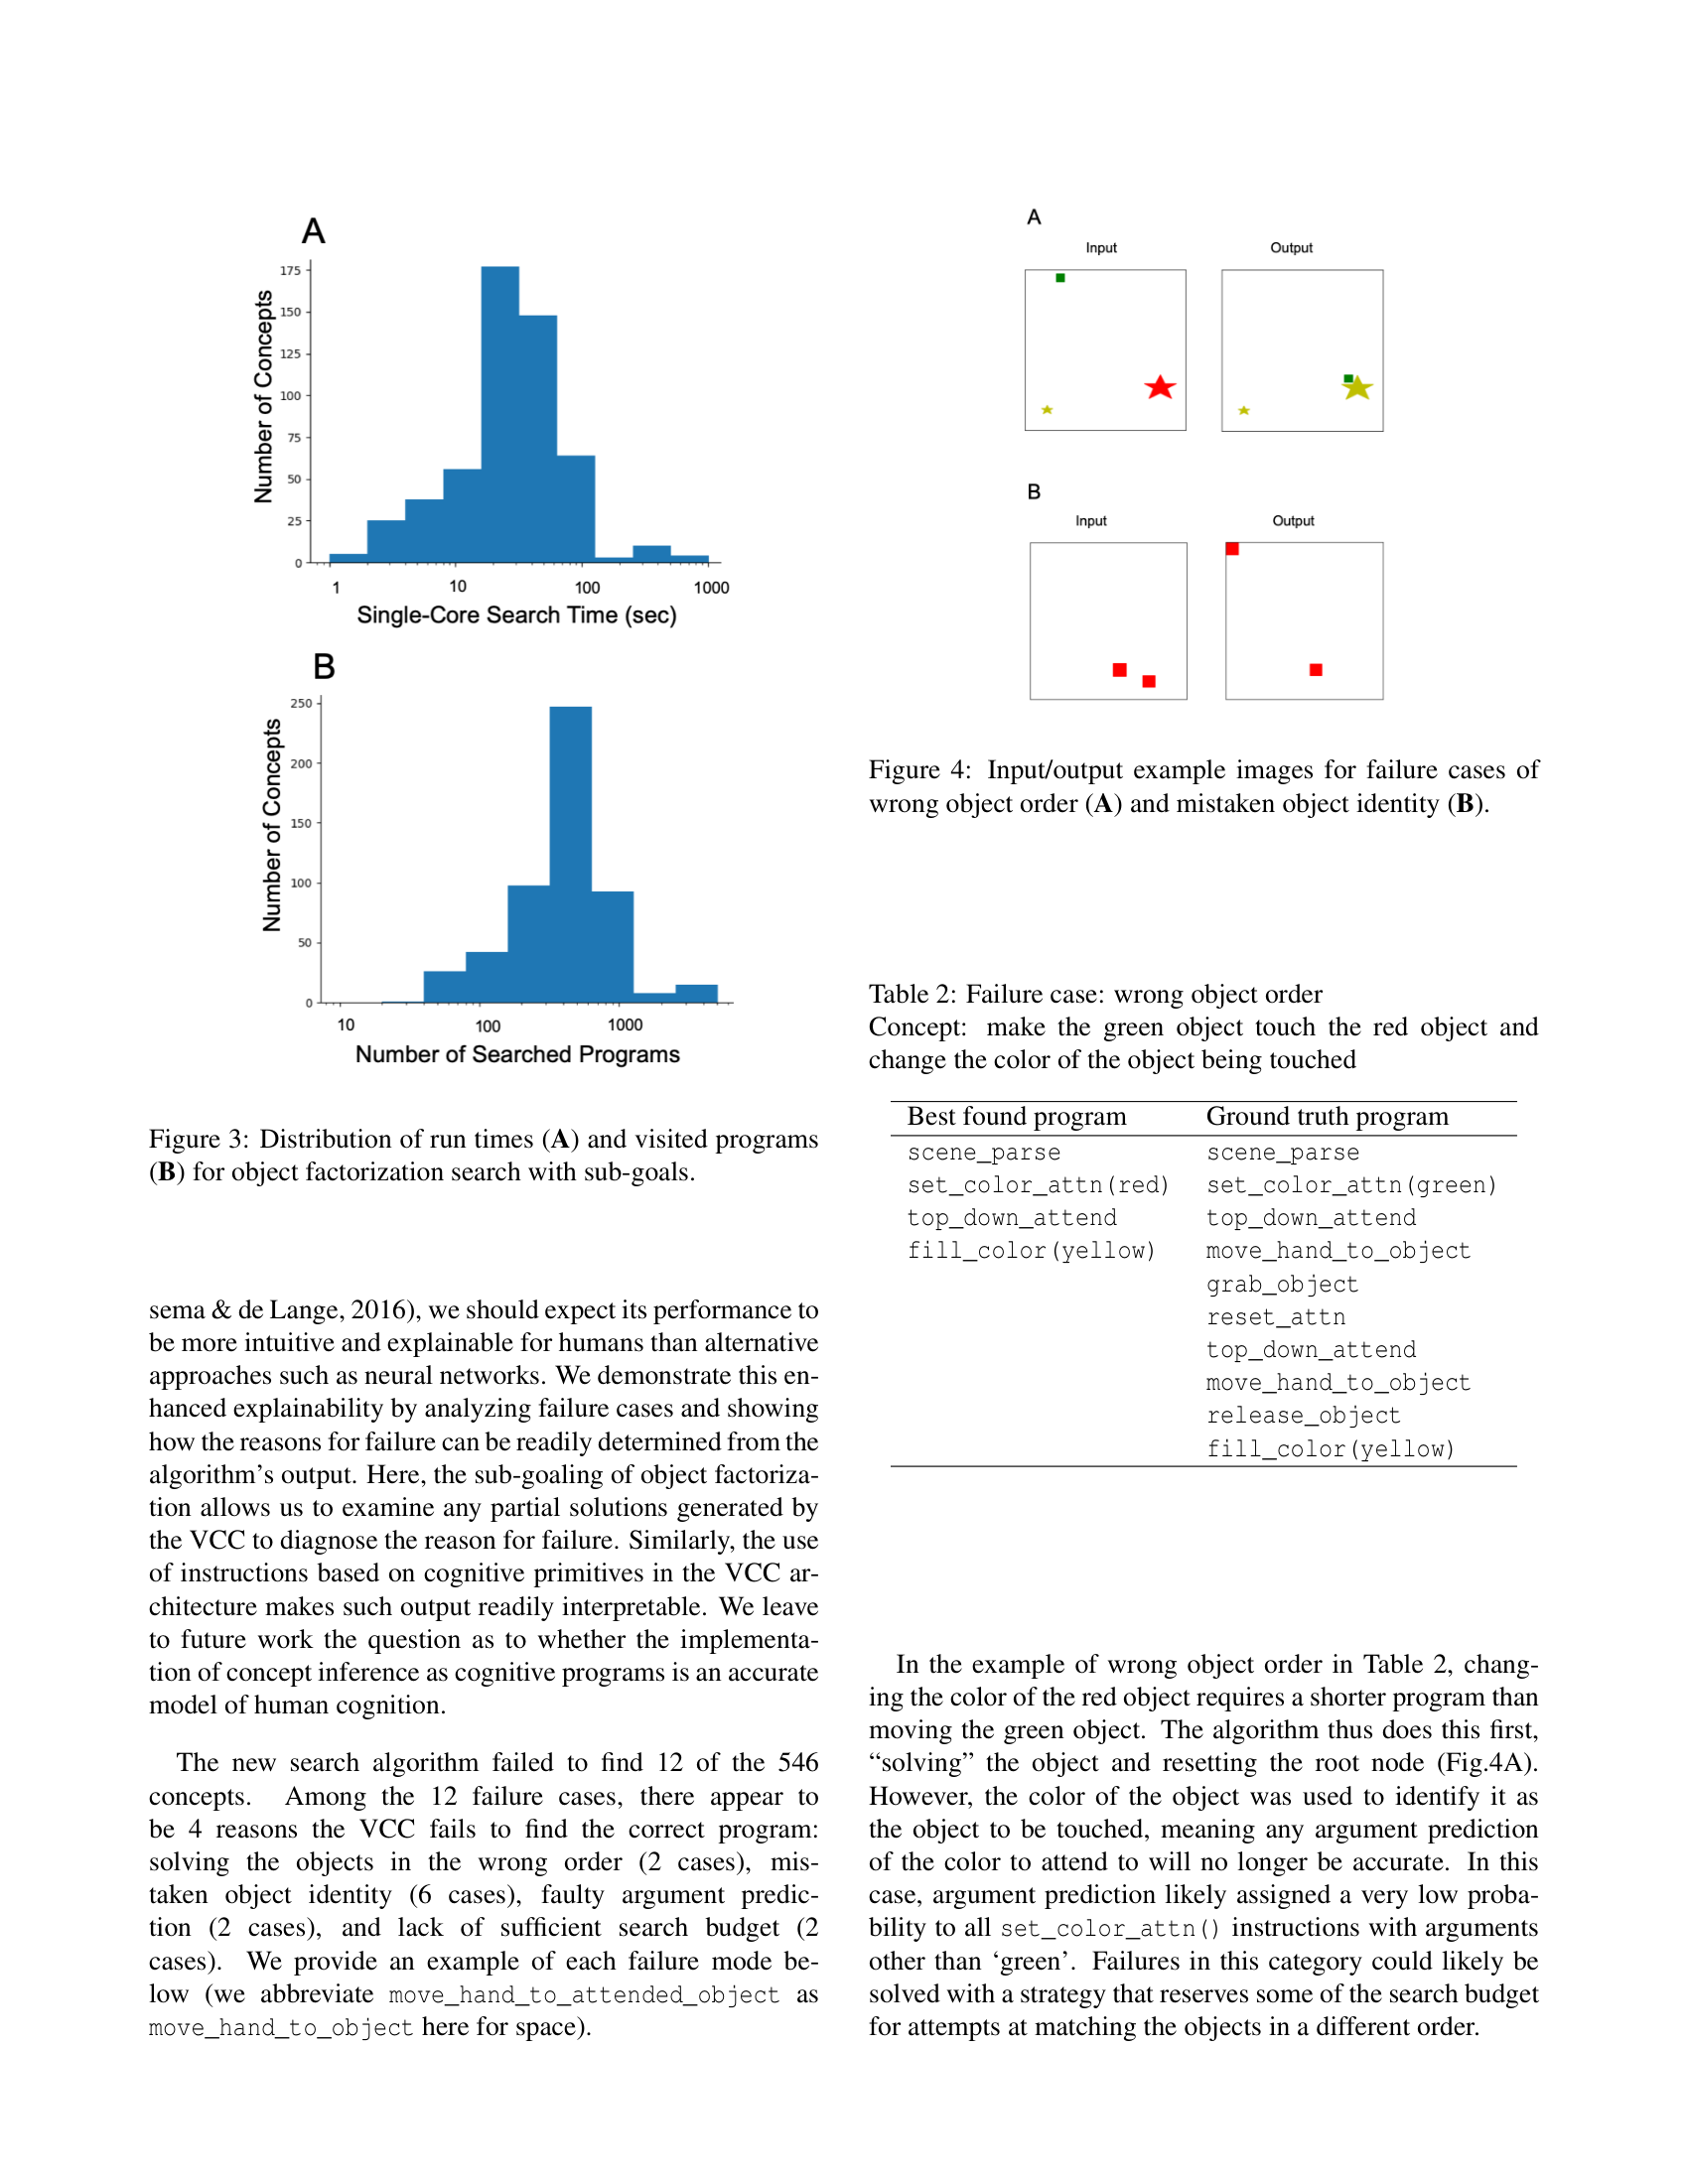

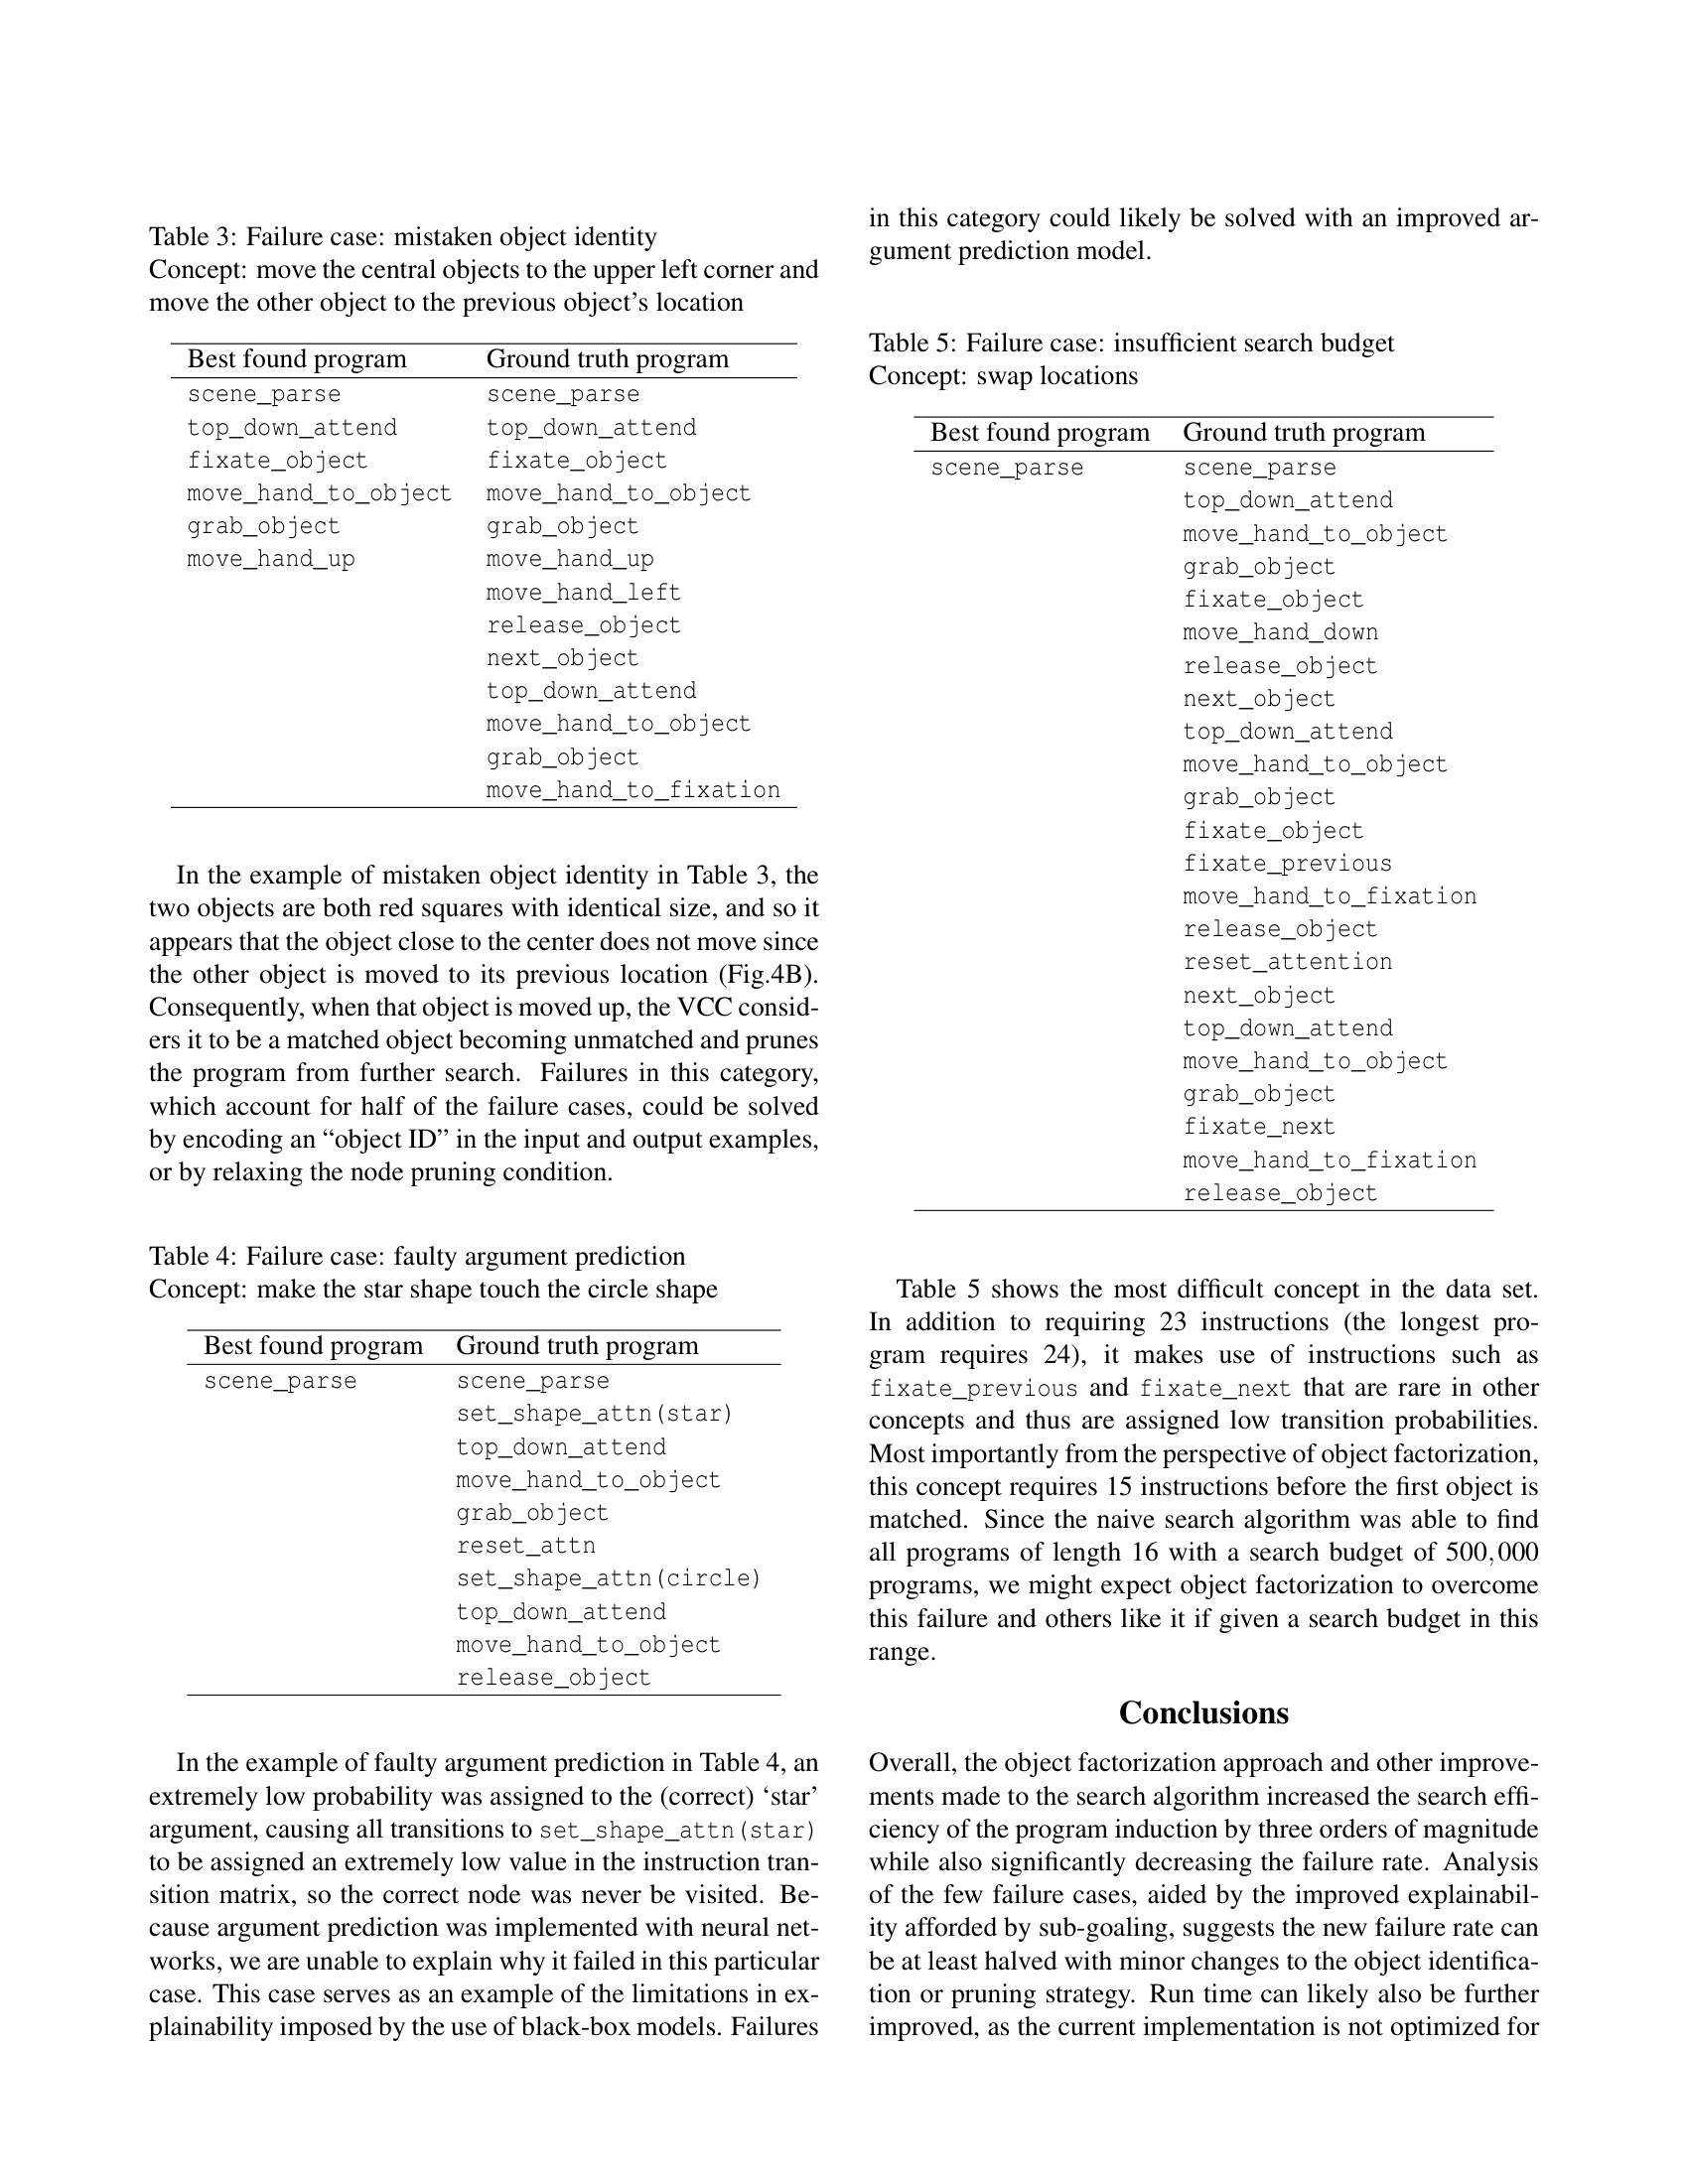

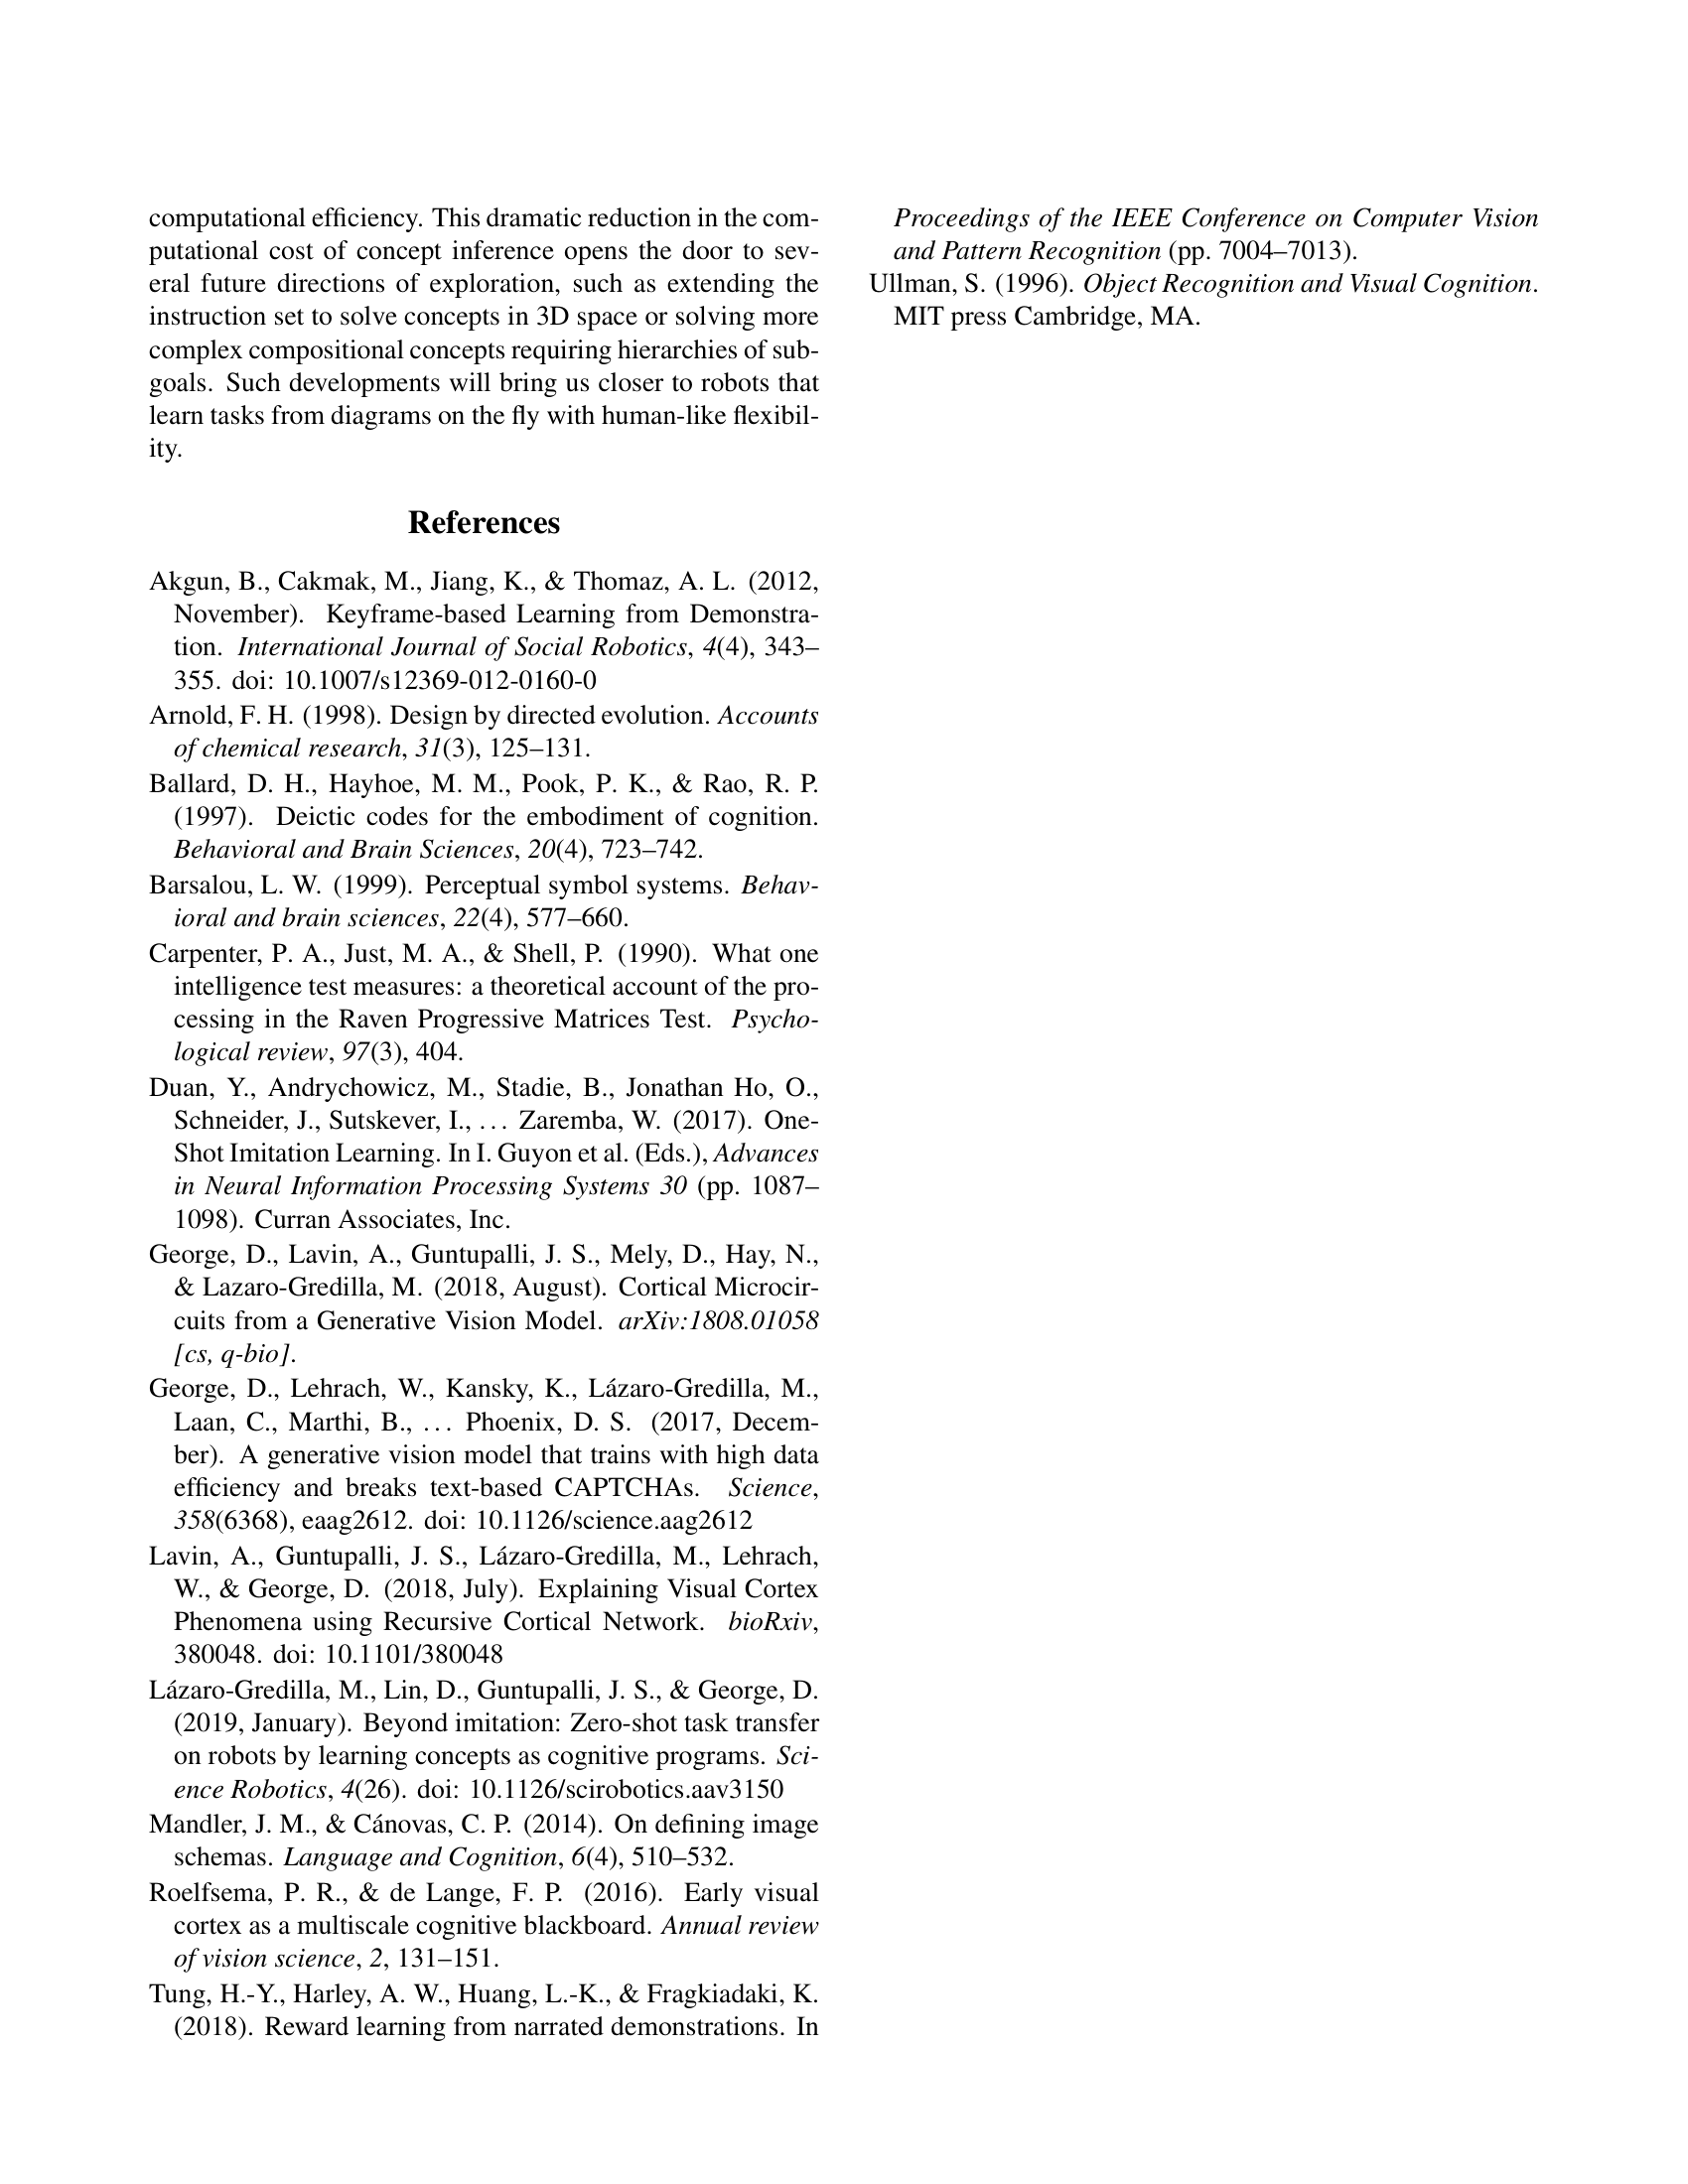

In [26]:
# Non-interactive use: edit ROW_POS and rerun.
ROW_POS = 10
show_row(ROW_POS, max_pages=12, image_width=520, mode="involved_neighbors")


## Interactive Browser

Requires `ipywidgets`. If widgets are unavailable, use `show_row(...)` above.


In [17]:
try:
    import ipywidgets as widgets

    family = widgets.Dropdown(
        options=["all"] + sorted(view["family"].dropna().unique().tolist()),
        value="all",
        description="family",
        layout=widgets.Layout(width="360px"),
    )
    multi = widgets.Dropdown(
        options=[("all", "all"), ("multi", "multi"), ("single", "single")],
        value="all",
        description="answers",
        layout=widgets.Layout(width="260px"),
    )
    row_dropdown = widgets.Dropdown(description="row", layout=widgets.Layout(width="980px"))
    max_pages = widgets.IntSlider(value=8, min=1, max=40, step=1, description="max pages")
    width = widgets.IntSlider(value=520, min=260, max=1200, step=20, description="width")
    mode = widgets.Dropdown(
        options=["involved_neighbors", "involved_only", "all"],
        value="involved_neighbors",
        description="pages",
        layout=widgets.Layout(width="320px"),
    )
    out = widgets.Output()

    def filtered_rows():
        sub = view.copy()
        if family.value != "all":
            sub = sub[sub["family"] == family.value]
        if multi.value == "multi":
            sub = sub[sub["multi_answer"]]
        elif multi.value == "single":
            sub = sub[~sub["multi_answer"]]
        return sub

    def refresh_rows(*_):
        sub = filtered_rows()
        options = [
            (
                f"pos {r.row_pos} | src {r.source_idx} | {r.family} | {r.n_answer_items} ans | {r.new_question[:110]}",
                int(r.row_pos),
            )
            for r in sub.itertuples()
        ]
        row_dropdown.options = options
        if options:
            row_dropdown.value = options[0][1]

    def render(*_):
        with out:
            out.clear_output(wait=True)
            if row_dropdown.value is not None:
                show_row(row_dropdown.value, max_pages=max_pages.value, image_width=width.value, mode=mode.value)

    family.observe(refresh_rows, names="value")
    multi.observe(refresh_rows, names="value")
    row_dropdown.observe(render, names="value")
    max_pages.observe(render, names="value")
    width.observe(render, names="value")
    mode.observe(render, names="value")

    refresh_rows()
    controls = widgets.VBox([
        widgets.HBox([family, multi]),
        row_dropdown,
        widgets.HBox([mode, max_pages, width]),
    ])
    display(controls, out)
    render()
except ImportError:
    print("ipywidgets is not installed. Use show_row(row_pos, ...) manually instead.")


Output()

## Optional: LongDocURL Style Examples

This loads structural LongDocURL rows and shows sampled examples by family for style comparison.


In [18]:
def longdoc_family(row) -> str:
    extra = as_dict(row.get("extra_info"))
    text = f"{extra.get('question_id', '')} {row.get('data_source', '')} {get_user_question(row.get('prompt'))}".lower()
    for family in ["summary2title", "summary2tab", "topic2title", "extract_fig2tab"]:
        if family in text:
            return family
    if "free" in text:
        return "free"
    return "other"


if LONGDOCURL_PATH.exists():
    long_df = pd.read_parquet(LONGDOCURL_PATH)
    long_rows = []
    for idx, row in long_df.iterrows():
        family = longdoc_family(row)
        if family not in {"summary2title", "summary2tab", "topic2title", "extract_fig2tab"}:
            continue
        answer_items = get_answer_items(row)
        long_rows.append(
            {
                "row_idx": idx,
                "family": family,
                "n_images": len(as_list(row.get("images"))),
                "n_answer_items": len(answer_items),
                "multi_answer": len(answer_items) > 1,
                "question": get_user_question(row.get("prompt")),
                "ground_truth": get_ground_truth(row),
            }
        )
    long_view = pd.DataFrame(long_rows)
    display(
        long_view.groupby("family")
        .agg(
            rows=("row_idx", "count"),
            multi_answer_rate=("multi_answer", "mean"),
            mean_answer_items=("n_answer_items", "mean"),
            mean_images=("n_images", "mean"),
        )
        .round(3)
        .reset_index()
    )

    EXAMPLE_FAMILY = "topic2title"
    display(long_view[long_view["family"] == EXAMPLE_FAMILY][["question", "ground_truth", "n_answer_items", "n_images"]].sample(min(8, (long_view["family"] == EXAMPLE_FAMILY).sum()), random_state=7))
else:
    print(f"LongDocURL parquet not found: {LONGDOCURL_PATH}")


,family,rows,multi_answer_rate,mean_answer_items,mean_images
0,extract_fig2tab,220,0.200,1.300,28.586
1,summary2tab,123,0.805,2.098,7.041
2,summary2title,130,0.000,0.992,26.077
3,topic2title,192,0.885,2.432,5.141


,question,ground_truth,n_answer_items,n_images
61,"Which sections provide insights into the impact of affordable housing outcomes on future annual action plans and the number of low-income persons served?\nSelect titles from the doc that best answer the question, do ...","[""CR-20-Affordable Housing 91.520(b)"", ""CR-05 - Goals and Outcomes""]",2,12
544,"Where can we find information about Energoprojekt's activities and growth in the new millennium?\nSelect titles from the doc that best answer the question, do not alter or analyze the titles themselves.","[""NEW MILLENIUM2001-2011""]",1,1
163,"Which sections discuss the operational aspects and performance of different business segments within the company?\nSelect titles from the doc that best answer the question, do not alter or analyze the titles themselves.","[""PERFORMANCE OF BUSINESS UNITS"", ""SKANO FURNITURE： RETAIL SALES""]",2,2
263,"Which sections cover the historical slope stability and measures needed to mitigate potential environmental impacts at the Newport Banning Ranch site?\nSelect titles from the doc that best answer the question, do not...","[""HISTORIC SLOPE STABILITY"", ""BLUFF SLOPE RETREAT""]",2,3
66,"Where can we find detailed financial information and accounting policies used in the preparation of the financial statements?\nSelect titles from the doc that best answer the question, do not alter or analyze the tit...","[""CONSOLIDATED FINANCIAL STATEMENTS"", ""NOTES TO THE CONSOLIDATED FINANCIAL STATEMENTS""]",2,5
303,"Which sections should be referred to for understanding the impact of Covid-19 on the NHS staff?\nSelect titles from the doc that best answer the question, do not alter or analyze the titles themselves.","[""Theme results -Covid-19classification breakdowns"", ""Covid-19 questions""]",2,2
124,"Where can we find information on the importance and mechanisms of synchronization in RISC-V architecture?\nSelect titles from the doc that best answer the question, do not alter or analyze the titles themselves.","[""Synchronization in RISC-V："", ""Review of Last Lecture (2/3)""]",2,1
658,"Which sections discuss the national, regional, and local policy objectives that impact Limerick City?\nSelect titles from the doc that best answer the question, do not alter or analyze the titles themselves.","[""2.11National Policy Objectives"", ""2.2Regional Policy Objectives"", ""2.3Local Policy Objectives""]",3,6
